# SNN + Rastermap Demo

This notebook demonstrates the full pipeline from a spiking neural network (SNN) to Rastermap visualization.

**The pipeline:**
1. Load real neural spike data (rat hippocampus) as input to the SNN
2. Build a small 2-layer SNN using snntorch (LIF neurons)
3. Run the data through the SNN and record spike activations at each layer
4. Feed those activations into Rastermap to sort and visualize the neurons
5. Compare different Rastermap settings (locality=0 vs locality=0.75)

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import snntorch as snn
from rastermap import Rastermap, utils
from scipy.stats import zscore

In [23]:
# load the hippocampus dataset
filename = utils.download_data(data_type="hippocampus")
dat = np.load(filename)

# spike matrix: neurons x time
spks = dat["spks"].astype("float32")
n_neurons, n_time = spks.shape
print(f"Data shape: {n_neurons} neurons x {n_time} timepoints")

# normalize
spks = zscore(spks, axis=1).astype("float32")

Data shape: 137 neurons x 10338 timepoints


## Build a Small SNN

We build a 2-layer SNN using Leaky Integrate-and-Fire (LIF) neurons from snntorch.
The network takes the 137 hippocampus neurons as input and passes them through
2 hidden layers of 256 LIF neurons each, recording the spike activations at every timestep.

In [24]:
# network dimensions
n_input = n_neurons # 137 — one input per hippocampus neuron
n_hidden = 256 # neurons per hidden layer
beta = 0.95 # membrane decay rate (how much voltage leaks per timestep)

# define the SNN
class SmallSNN(nn.Module):
    def __init__(self):
        super().__init__()
        # linear layers (weights)
        self.fc1 = nn.Linear(n_input, n_hidden)
        self.fc2 = nn.Linear(n_hidden, n_hidden)
        
        # LIF neurons for each layer
        self.lif1 = snn.Leaky(beta=beta)
        self.lif2 = snn.Leaky(beta=beta)
    
    def forward(self, x, mem1, mem2):
        # layer 1
        cur1 = self.fc1(x)
        spk1, mem1 = self.lif1(cur1, mem1)
        
        # layer 2
        cur2 = self.fc2(spk1)
        spk2, mem2 = self.lif2(cur2, mem2)
        
        return spk1, spk2, mem1, mem2

model = SmallSNN()
print(model)

SmallSNN(
  (fc1): Linear(in_features=137, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (lif1): Leaky()
  (lif2): Leaky()
)


## Record Spike Activations

We run the hippocampus data through the SNN one timestep at a time,
recording the spike activations at each layer. This gives us two matrices
of shape (256 neurons x 10338 timepoints) - one per layer.

In [25]:
# store spike recordings for each layer
spk1_rec = []
spk2_rec = []

# initialize membrane potentials to zero
mem1 = torch.zeros(1, n_hidden)
mem2 = torch.zeros(1, n_hidden)

# run through data one timestep at a time (no training, just forward pass)
model.eval()
with torch.no_grad():
    for t in range(n_time):
        # get input at this timestep: shape (1, 137)
        x = torch.tensor(spks[:, t]).unsqueeze(0)
        
        # forward pass
        spk1, spk2, mem1, mem2 = model(x, mem1, mem2)
        
        # record spikes
        spk1_rec.append(spk1.squeeze(0).numpy())
        spk2_rec.append(spk2.squeeze(0).numpy())

# convert to numpy arrays: shape (n_hidden x n_time)
spk1_rec = np.array(spk1_rec).T  # (256 x 10338)
spk2_rec = np.array(spk2_rec).T  # (256 x 10338)

print(f"Layer 1 spikes shape: {spk1_rec.shape}")
print(f"Layer 2 spikes shape: {spk2_rec.shape}")
print(f"Layer 1 firing rate: {spk1_rec.mean():.3f}")
print(f"Layer 2 firing rate: {spk2_rec.mean():.3f}")

Layer 1 spikes shape: (256, 10338)
Layer 2 spikes shape: (256, 10338)
Layer 1 firing rate: 0.087
Layer 2 firing rate: 0.024


## Run Rastermap

We run Rastermap on the spike activations from each layer.
Since we have only 256 neurons we turn off clustering (n_clusters=None)
and sort individual neurons directly (like the hippocampus notebook in rastermap tutorial).

In [26]:
# run rastermap on layer 1
model_r1 = Rastermap(
    n_clusters=30,
    n_PCs=64,
    locality=0.75,
    time_lag_window=15,
    grid_upsample=10,
).fit(spk1_rec)

# run rastermap on layer 2
model_r2 = Rastermap(
    n_clusters=50,
    n_PCs=64,
    locality=0.75,
    time_lag_window=15,
    grid_upsample=0,
).fit(spk2_rec)

isort1 = model_r1.isort
isort2 = model_r2.isort

print("Rastermap done!")
print(f"isort1 shape: {isort1.shape}")
print(f"isort2 shape: {isort2.shape}")

2026-03-02 11:56:03,239 [INFO] normalizing data across axis=1
2026-03-02 11:56:03,243 [INFO] projecting out mean along axis=0
2026-03-02 11:56:03,249 [INFO] data normalized, 0.01sec
2026-03-02 11:56:03,249 [INFO] sorting activity: 256 valid samples by 10338 timepoints
2026-03-02 11:56:03,287 [INFO] n_PCs = 64 computed, 0.05sec
2026-03-02 11:56:03,295 [INFO] 17 clusters computed, time 0.06sec
2026-03-02 11:56:03,306 [INFO] clusters sorted, time 0.07sec
2026-03-02 11:56:03,310 [INFO] clusters upsampled, time 0.07sec
2026-03-02 11:56:03,318 [INFO] rastermap complete, time 0.08sec
2026-03-02 11:56:03,319 [INFO] normalizing data across axis=1
2026-03-02 11:56:03,324 [INFO] projecting out mean along axis=0
2026-03-02 11:56:03,330 [INFO] data normalized, 0.01sec
2026-03-02 11:56:03,331 [INFO] sorting activity: 241 valid samples by 10338 timepoints
2026-03-02 11:56:03,369 [INFO] n_PCs = 64 computed, 0.05sec
2026-03-02 11:56:03,380 [INFO] 27 clusters computed, time 0.06sec
2026-03-02 11:56:03,4

/Users/katelynsadorf/miniforge3/envs/rastermap/lib/python3.12/site-packages/rastermap/rastermap.py:278: RuntimeWarning: invalid value encountered in divide
  X /= stdx[:,np.newaxis]


## Visualize Sorted Spike Rasters

We plot the Rastermap-sorted spike activations for both layers,
with the rat's position overlaid so we can see if any neurons
show place-field-like structure.

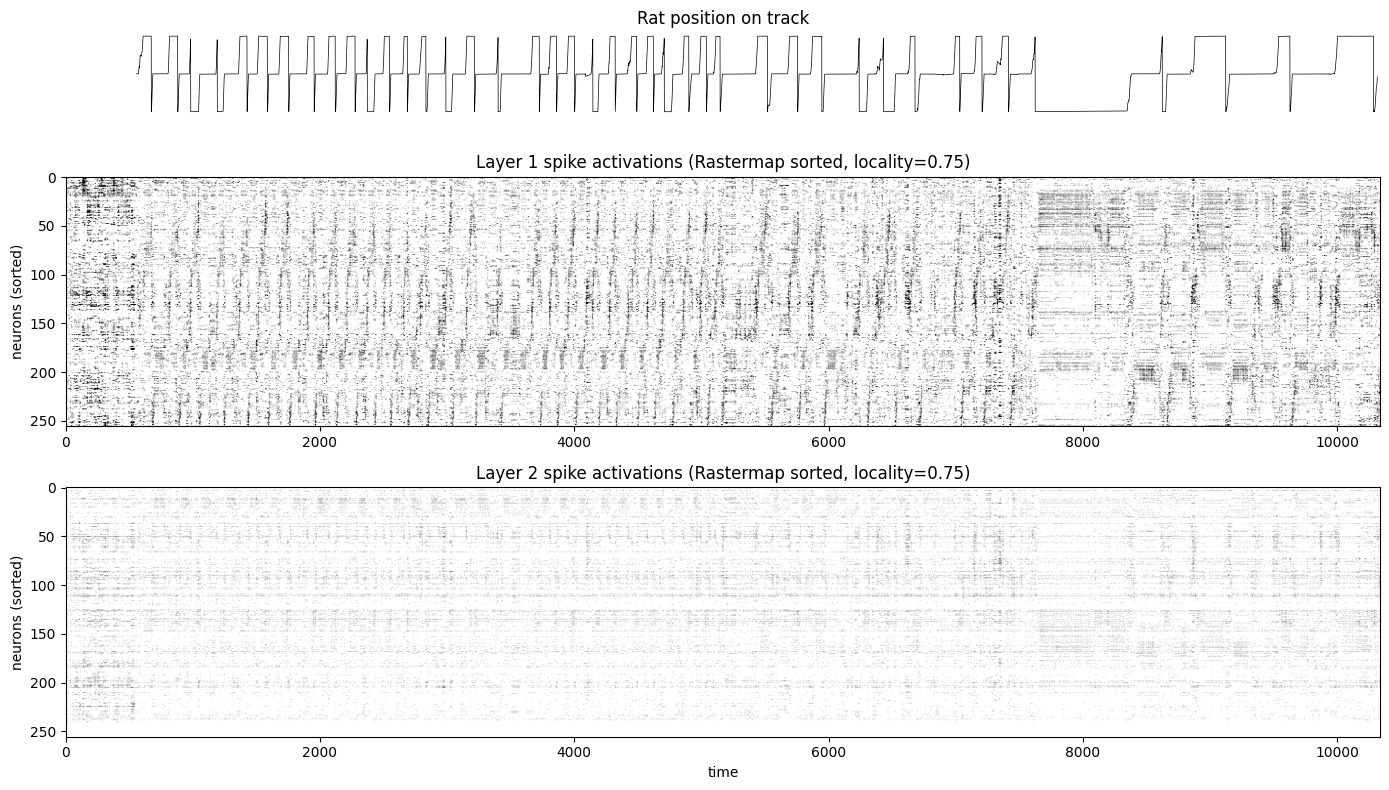

In [27]:
# load rat position for overlay
loc = dat["loc_signed"]  # rat's position on the track over time

fig, axes = plt.subplots(3, 1, figsize=(14, 8), 
                          gridspec_kw={"height_ratios": [1, 3, 3]})

# plot rat position
axes[0].plot(loc, color="black", linewidth=0.5)
axes[0].set_xlim([0, n_time])
axes[0].set_ylabel("position")
axes[0].set_title("Rat position on track")
axes[0].axis("off")

# plot layer 1 sorted spikes
axes[1].imshow(spk1_rec[isort1], cmap="gray_r", vmin=0, vmax=0.3, aspect="auto")
axes[1].set_ylabel("neurons (sorted)")
axes[1].set_title("Layer 1 spike activations (Rastermap sorted, locality=0.75)")

# plot layer 2 sorted spikes
axes[2].imshow(spk2_rec[isort2], cmap="gray_r", vmin=0, vmax=0.3, aspect="auto")
axes[2].set_ylabel("neurons (sorted)")
axes[2].set_title("Layer 2 spike activations (Rastermap sorted, locality=0.75)")
axes[2].set_xlabel("time")

plt.tight_layout()
plt.savefig("raster_locality075.png", dpi=150, bbox_inches="tight")
plt.show()

2026-03-02 11:56:04,355 [INFO] normalizing data across axis=1
2026-03-02 11:56:04,361 [INFO] projecting out mean along axis=0
2026-03-02 11:56:04,369 [INFO] data normalized, 0.01sec
2026-03-02 11:56:04,369 [INFO] sorting activity: 256 valid samples by 10338 timepoints
2026-03-02 11:56:04,410 [INFO] n_PCs = 64 computed, 0.05sec
2026-03-02 11:56:04,418 [INFO] 17 clusters computed, time 0.06sec
2026-03-02 11:56:04,429 [INFO] clusters sorted, time 0.07sec
2026-03-02 11:56:04,435 [INFO] clusters upsampled, time 0.08sec
2026-03-02 11:56:04,443 [INFO] rastermap complete, time 0.09sec


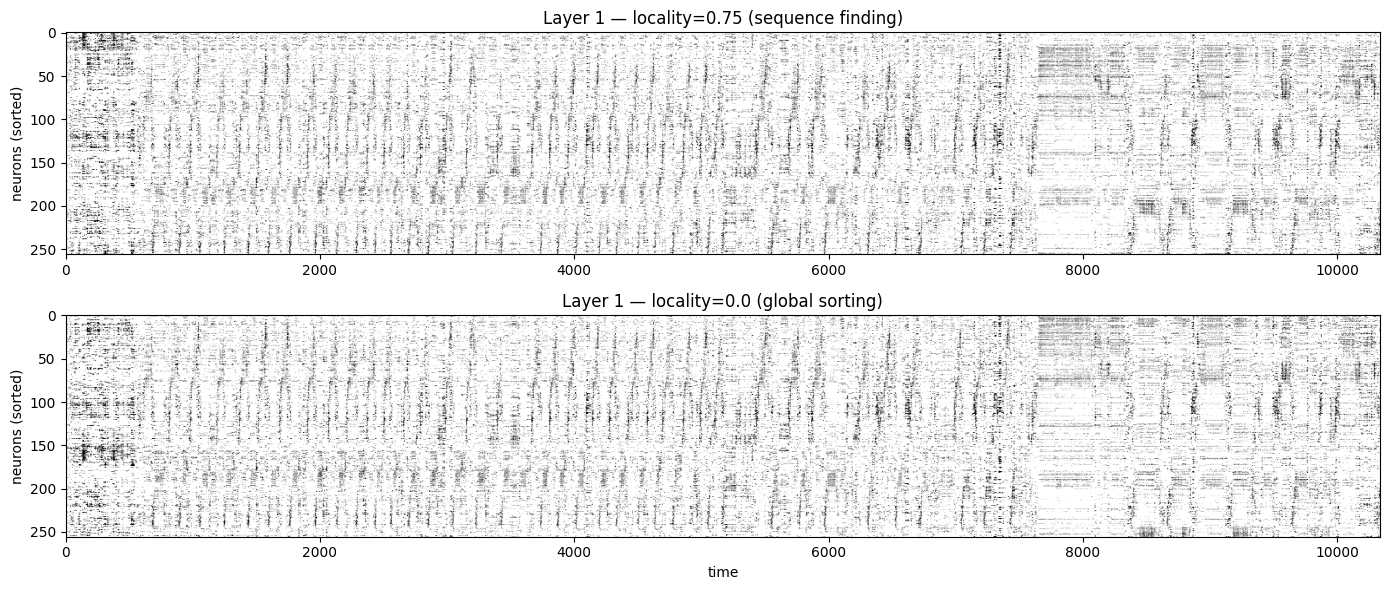

In [28]:
# rerun rastermap on layer 1 with locality=0 for comparison
model_r1_global = Rastermap(
    n_clusters=30,
    n_PCs=64,
    locality=0.0,
    time_lag_window=15,
    grid_upsample=10,
).fit(spk1_rec)

isort1_global = model_r1_global.isort

# plot comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].imshow(spk1_rec[isort1], cmap="gray_r", vmin=0, vmax=0.3, aspect="auto")
axes[0].set_ylabel("neurons (sorted)")
axes[0].set_title("Layer 1 — locality=0.75 (sequence finding)")

axes[1].imshow(spk1_rec[isort1_global], cmap="gray_r", vmin=0, vmax=0.3, aspect="auto")
axes[1].set_ylabel("neurons (sorted)")
axes[1].set_title("Layer 1 — locality=0.0 (global sorting)")
axes[1].set_xlabel("time")

plt.tight_layout()
plt.savefig("raster_locality_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

This notebook demonstrated the full SNN → Rastermap pipeline:

1. **Data**: 137 rat hippocampus neurons (10,338 timepoints) used as input
2. **SNN**: 2-layer LIF network (256 neurons/layer, beta=0.95) built with snntorch
3. **Spike recording**: Layer 1 firing rate ~9%, Layer 2 ~2.6% - signal naturally 
   gets sparser in deeper layers of an untrained network
4. **Rastermap**: Successfully sorted neurons in both layers, revealing that Layer 1 
   picks up structure from the input while Layer 2 (too sparse) shows little structure
5. **Locality comparison**: locality=0.75 vs locality=0.0 produces different orderings 
   of the same neurons - high locality emphasizes sequential patterns, low locality 
   emphasizes global co-firing

## Superneuron Traces & Input Correlation

Now that Rastermap has sorted neurons into clusters, we can ask:
**what does each cluster actually respond to?**

The approach:
1. **Superneurons**: average the spike activity of all neurons within each Rastermap cluster → one representative trace per cluster
2. **Input correlation**: correlate each superneuron trace against each of the 137 hippocampus input neurons → reveals which inputs drive each cluster
3. **Visualize**: plot superneuron traces and the input correlation heatmap

This is the first step toward *interpretability* - mapping internal model dynamics back to the input space.

In [29]:
# Step 1: Compute superneurons
# Each Rastermap cluster gets one trace: the mean spike activity of its neurons.
# model_r1.isort gives us the sorted neuron indices; model_r1.embedding gives
# the 1D position of each neuron in [0, 1]. We use n_clusters to bin them.

n_superneurons = 30  # match n_clusters used in model_r1

# assign each neuron to a superneuron bin based on its sorted position
neuron_positions = np.argsort(isort1)  # rank of each neuron in the sorted order
bin_assignments = (neuron_positions / len(isort1) * n_superneurons).astype(int)
bin_assignments = np.clip(bin_assignments, 0, n_superneurons - 1)

# compute mean activity per bin → shape: (n_superneurons, n_time)
superneurons = np.zeros((n_superneurons, n_time))
for b in range(n_superneurons):
    mask = bin_assignments == b
    if mask.sum() > 0:
        superneurons[b] = spk1_rec[mask].mean(axis=0)

print(f"Superneurons shape: {superneurons.shape}")
print(f"Neurons per bin (approx): {len(isort1) / n_superneurons:.1f}")

Superneurons shape: (30, 10338)
Neurons per bin (approx): 8.5


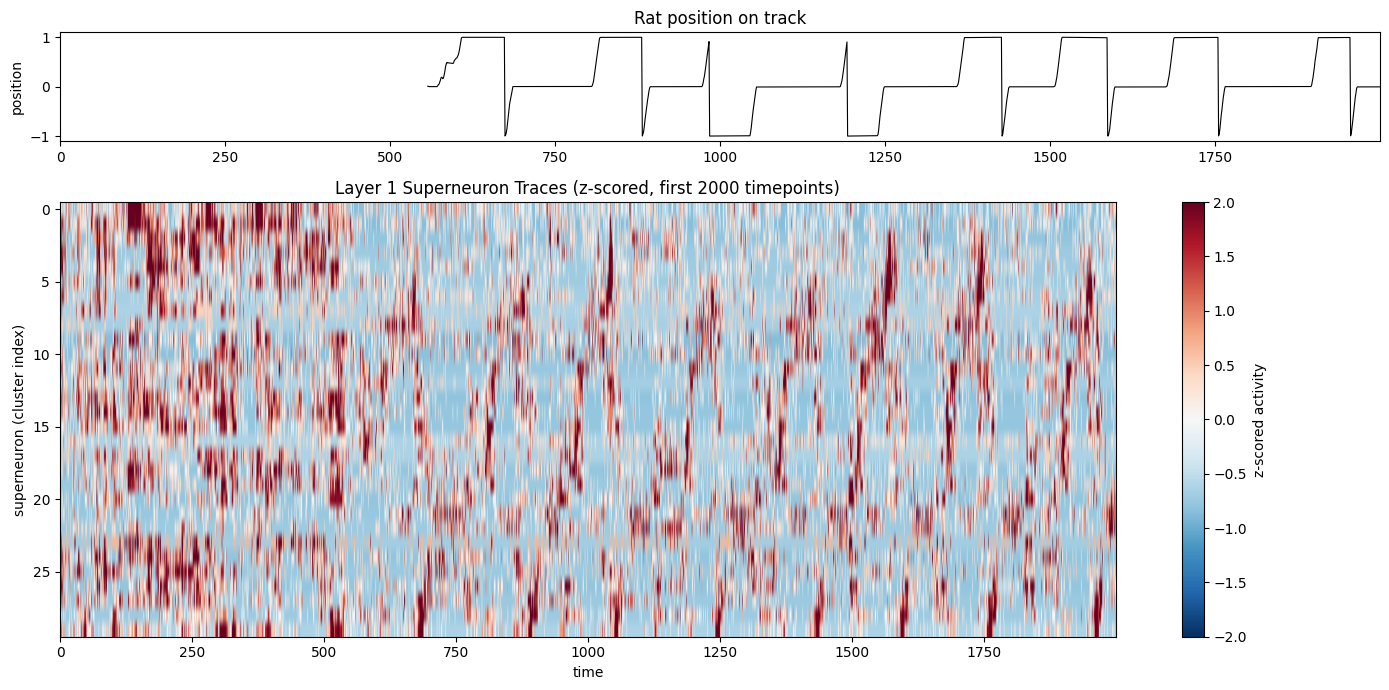

Saved: superneuron_traces.png


In [45]:
# Step 2: Plot superneuron traces
# Each row is one superneuron. We normalize each trace for display clarity.
# The rat's position is shown on top for reference.

# pick a time window to zoom in on (first 2000 timepoints)
t_start, t_end = 0, 2000

# z-score each superneuron trace for display
sn_display = zscore(superneurons[:, t_start:t_end], axis=1)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), gridspec_kw={"height_ratios": [1, 4]})

# top: rat position
axes[0].plot(loc[t_start:t_end], color='black', linewidth=0.8)
axes[0].set_ylabel('position')
axes[0].set_title('Rat position on track')
axes[0].margins(x=0)

# bottom: superneuron traces as heatmap
im = axes[1].imshow(sn_display, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
axes[0].set_xlim(axes[1].get_xlim())  # sync after imshow
axes[1].set_ylabel('superneuron (cluster index)')
axes[1].set_xlabel('time')
axes[1].set_title('Layer 1 Superneuron Traces (z-scored, first 2000 timepoints)')

plt.colorbar(im, ax=axes[1], label='z-scored activity')
plt.tight_layout()
plt.savefig('superneuron_traces.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: superneuron_traces.png')

### Input Correlation

Next we ask: **which input neurons does each superneuron correlate with?**

We compute the Pearson correlation between every superneuron trace and every
input neuron trace → a matrix of shape `(n_superneurons, n_input_neurons)`.

High correlation = that cluster's activity tracks that input neuron closely.
This tells us whether the SNN is preserving, transforming, or discarding input structure.

In [46]:
# Step 3: Correlate superneurons with input neurons
# spks shape: (n_input_neurons=137, n_time)
# superneurons shape: (n_superneurons=30, n_time)
# output corr_matrix shape: (n_superneurons, n_input_neurons)

from scipy.stats import pearsonr

corr_matrix = np.zeros((n_superneurons, n_neurons))  # n_neurons = 137 input neurons

for i in range(n_superneurons):
    for j in range(n_neurons):
        r, _ = pearsonr(superneurons[i], spks[j])
        corr_matrix[i, j] = r

print(f"Correlation matrix shape: {corr_matrix.shape}")
print(f"Max correlation: {corr_matrix.max():.3f}")
print(f"Mean absolute correlation: {np.abs(corr_matrix).mean():.3f}")

Correlation matrix shape: (30, 137)
Max correlation: 0.517
Mean absolute correlation: 0.078


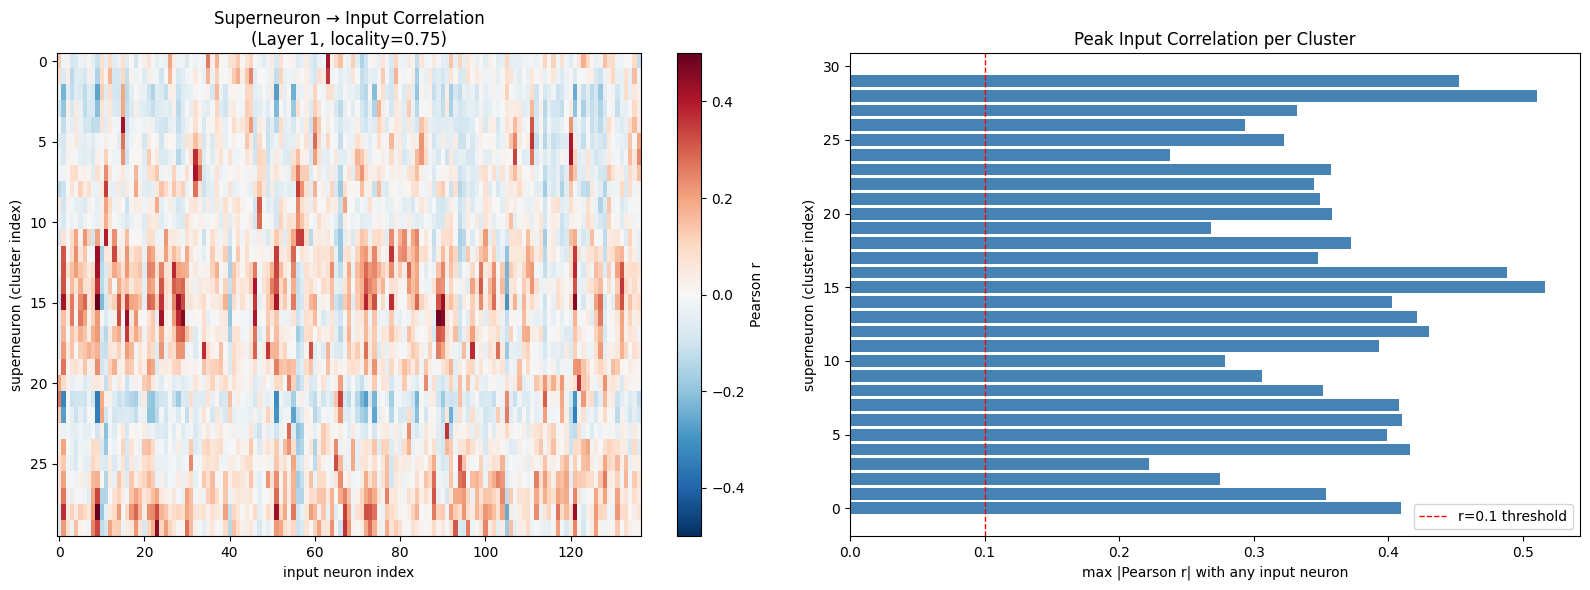

Saved: input_correlation.png


In [47]:
# Step 4: Visualize the correlation matrix
# Rows = superneurons (clusters), Columns = input neurons
# A strong horizontal stripe = that cluster tracks many input neurons
# A strong vertical stripe = that input neuron drives many clusters

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# left: full correlation heatmap
im = axes[0].imshow(corr_matrix, cmap='RdBu_r', aspect='auto',
                     vmin=-0.5, vmax=0.5)
axes[0].set_xlabel('input neuron index')
axes[0].set_ylabel('superneuron (cluster index)')
axes[0].set_title('Superneuron → Input Correlation\n(Layer 1, locality=0.75)')
plt.colorbar(im, ax=axes[0], label='Pearson r')

# right: max absolute correlation per superneuron
# → which cluster is most strongly driven by any single input?
max_corr_per_cluster = np.abs(corr_matrix).max(axis=1)
axes[1].barh(np.arange(n_superneurons), max_corr_per_cluster, color='steelblue')
axes[1].set_xlabel('max |Pearson r| with any input neuron')
axes[1].set_ylabel('superneuron (cluster index)')
axes[1].set_title('Peak Input Correlation per Cluster')
axes[1].axvline(0.1, color='red', linestyle='--', linewidth=1, label='r=0.1 threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig('input_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: input_correlation.png')

In [48]:
# Step 5: Find the top input drivers per superneuron
# For each cluster, which input neurons correlate most strongly?
# This is a simple readout table — useful for understanding what drives each cluster.

top_k = 3  # how many top input neurons to show per cluster

print(f"Top-{top_k} input neuron drivers per superneuron cluster:\n")
print(f"{'Cluster':>8} | {'Top input neurons (idx)':>30} | {'Max |r|':>8} | {'Mean |r|':>9}")
print("-" * 65)

for i in range(n_superneurons):
    abs_corr = np.abs(corr_matrix[i])
    top_idx = np.argsort(abs_corr)[::-1][:top_k]
    top_str = ', '.join([f'{idx}(r={corr_matrix[i,idx]:.2f})' for idx in top_idx])
    print(f"{i:>8} | {top_str:>30} | {abs_corr.max():>8.3f} | {abs_corr.mean():>9.3f}")

Top-3 input neuron drivers per superneuron cluster:

 Cluster |        Top input neurons (idx) |  Max |r| |  Mean |r|
-----------------------------------------------------------------
       0 | 63(r=0.41), 35(r=0.26), 26(r=0.20) |    0.410 |     0.056
       1 | 63(r=0.35), 45(r=0.24), 42(r=0.18) |    0.354 |     0.057
       2 | 51(r=-0.27), 9(r=-0.27), 121(r=-0.25) |    0.275 |     0.068
       3 | 51(r=-0.22), 9(r=-0.21), 121(r=-0.20) |    0.222 |     0.067
       4 | 15(r=0.42), 111(r=0.31), 120(r=0.22) |    0.416 |     0.066
       5 | 120(r=0.40), 111(r=0.36), 60(r=0.28) |    0.399 |     0.062
       6 | 120(r=0.41), 32(r=0.37), 107(r=0.34) |    0.410 |     0.065
       7 | 32(r=0.41), 33(r=0.28), 56(r=0.26) |    0.408 |     0.063
       8 | 56(r=0.35), 11(r=0.35), 32(r=0.27) |    0.351 |     0.068
       9 | 47(r=0.31), 56(r=0.24), 67(r=0.20) |    0.306 |     0.048
      10 | 47(r=0.28), 56(r=0.23), 11(r=0.18) |    0.279 |     0.046
      11 | 11(r=0.39), 57(r=0.35), 56(r=0.35)

### What this tells us

- **Superneuron traces** show the collective rhythm of each cluster over time. If clusters show distinct patterns relative to the rat's position, the SNN is encoding spatial information.
- **The correlation matrix** tells us how much each cluster is driven by specific input neurons. High correlations in an untrained network mean those clusters happen to preserve certain input signals through random weights.
- **With a trained model** (e.g. Pavlos' activations from your ASR model), this same analysis would reveal *which speech features* each internal cluster responds to — the bridge to interpretability.

> **Next step**: Replace `spk1_rec` / `spks` with activations from the trained RSNN and input Whisper features to run this same pipeline on real ASR dynamics.